## 📐 Obstruction calculation


In [34]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
import importlib

# Add current directory to path
if '.' not in sys.path:
    sys.path.insert(0, '.')

# Import and reload to get latest changes
import viz_utils
importlib.reload(viz_utils)
from viz_utils import (HorizonAngleVisualizer, ZenithAngleVisualizer, TopViewVisualizer,
                       DualAngleVisualizer, DirectionVectorCalculator)

### 📡Setup Server Connection

Start the server: 

`python -m src.main`

In [35]:
SERVER_URL = "http://localhost:8081"
response = requests.get(f"{SERVER_URL}/")
print("Server Status:", response.json())

Server Status: {'services': {'raytrace_service': {'horizon_calculator': 'MaxHeightObstructionCalculator', 'projection_calculator': 'OrthographicProjectionCalculator', 'status': 'ready', 'zenith_calculator': 'ZenithAngleCalculator'}}, 'status': 'running'}


### 👉 Horizon angle

In [36]:
window_center = [0.0, 3.0, 0.0]
window_angles = [0.03, 0.0]  # Looking forward (+X)
building_dist, building_height, building_width = 10.0, 5.0, 10.0
mesh = [[building_dist, 0.0, -building_width/2], [building_dist, building_height, -building_width/2], [building_dist, 0.0, building_width/2],
        [building_dist, 0.0, building_width/2], [building_dist, building_height, -building_width/2], [building_dist, building_height, building_width/2]]
print(f"Window: {window_center}, Angles: {window_angles}")
print(f"Building: {building_dist}m away, {building_height}m tall, {building_width}m wide")

Window: [0.0, 3.0, 0.0], Angles: [0.03, 0.0]
Building: 10.0m away, 5.0m tall, 10.0m wide


In [37]:
request_data = {"x": window_center[0], 
                "y": window_center[1], 
                "z": window_center[2], 
                "rad_x": window_angles[0], 
                "rad_y": window_angles[1], 
                "mesh": mesh}
response = requests.post(f"{SERVER_URL}/horizon_angle", json=request_data)
result = response.json()
print("Result:", result)

Result: {'data': {'highest_point': {'x': 10.0, 'y': 5.0, 'z': -5.0}, 'obstruction_angle_degrees': 11.309932474020215, 'obstruction_angle_radians': 0.19739555984988078, 'projected_point_count': 6}, 'status': 'success'}


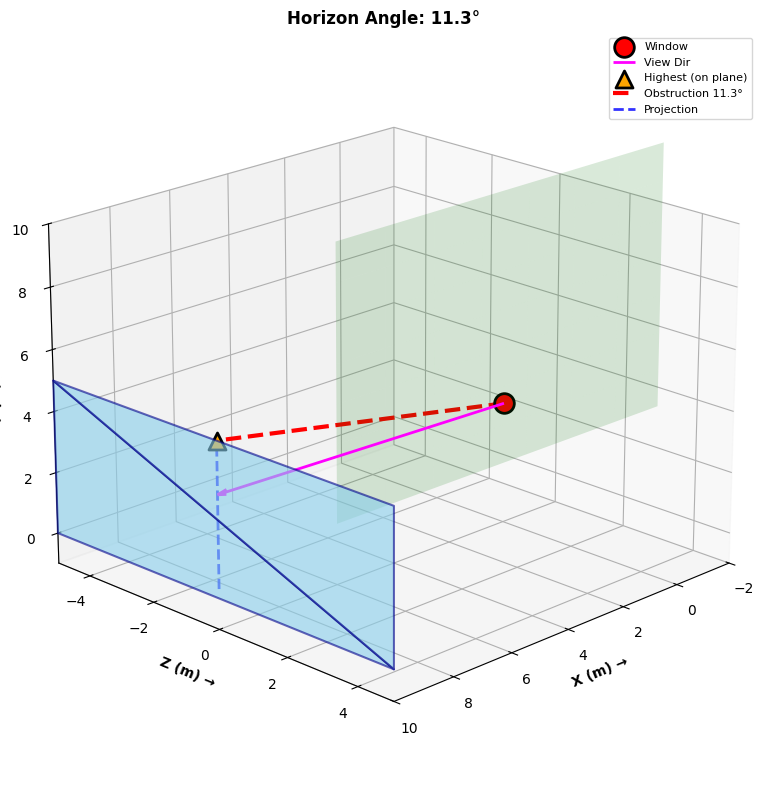

In [38]:
if result.get("status") == "success":
    data = result["data"]
    obstruction_degrees, obstruction_radians, highest_point = data["obstruction_angle_degrees"], data["obstruction_angle_radians"], data["highest_point"]
    # Create visualizer
    visualizer = HorizonAngleVisualizer(
        window_center=window_center,
        window_angles=window_angles,
        mesh_vertices=mesh,
        building_dimensions=(building_dist, building_height, building_width)
    )
    
    # Create figure and visualize
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')
    visualizer.visualize(ax, highest_point, obstruction_degrees)
    plt.tight_layout()
    plt.show()

### 👉 Zenith Angle Calculation

In [39]:
# Test zenith angle with the same building
response = requests.post(f"{SERVER_URL}/zenith_angle", json=request_data)
zenith_result = response.json()
print("Zenith Result:", zenith_result)

if zenith_result.get("status") == "success":
    data = zenith_result["data"]
    zenith_degrees = data["obstruction_angle_degrees"]
    zenith_radians = data["obstruction_angle_radians"]
    

Zenith Result: {'data': {'highest_point': None, 'obstruction_angle_degrees': 0.0, 'obstruction_angle_radians': 0.0, 'projected_point_count': 6}, 'status': 'success'}


### 👉 Overhead Obstruction Example

In [43]:
# Create a horizontal overhead mesh (like a balcony/roof)
# Window at (0, 3, 0), overhead obstruction at Y=7 (4m above window)
overhead_height = 7.0
overhead_distance = 5.0  # 5m away horizontally
overhead_width = 4.0

overhead_mesh = [
    # Horizontal rectangle above window
    [overhead_distance, overhead_height, -overhead_width/2],
    [overhead_distance, overhead_height, overhead_width/2],
    [overhead_distance + 3, overhead_height, -overhead_width/2],
    
    [overhead_distance, overhead_height, overhead_width/2],
    [overhead_distance + 3, overhead_height, overhead_width/2],
    [overhead_distance + 3, overhead_height, -overhead_width/2]
]

overhead_request = {
    "x": 0.0, "y": 3.0, "z": 0.0,
    "rad_x": 0.0, "rad_y": 0.0,  # Looking straight forward
    "mesh": overhead_mesh
}

# Calculate zenith angle
response = requests.post(f"{SERVER_URL}/zenith_angle", json=overhead_request)
overhead_result = response.json()

if overhead_result.get("status") == "success":
    data = overhead_result["data"]
    zenith_deg = data["obstruction_angle_degrees"]
    lowest_pt = data["highest_point"]
    
    print(f"Zenith Angle: {zenith_deg:.2f}°")
    if zenith_deg > 0:
        print(f"Furthest overhead point: ({lowest_pt['x']:.1f}, {lowest_pt['y']:.1f}, {lowest_pt['z']:.1f})")
    else:
        print("No overhead obstruction found on direction plane")
else:
    print("ERROR:", overhead_result.get("error"))

Zenith Angle: 63.43°
Furthest overhead point: (8.0, 7.0, -2.0)


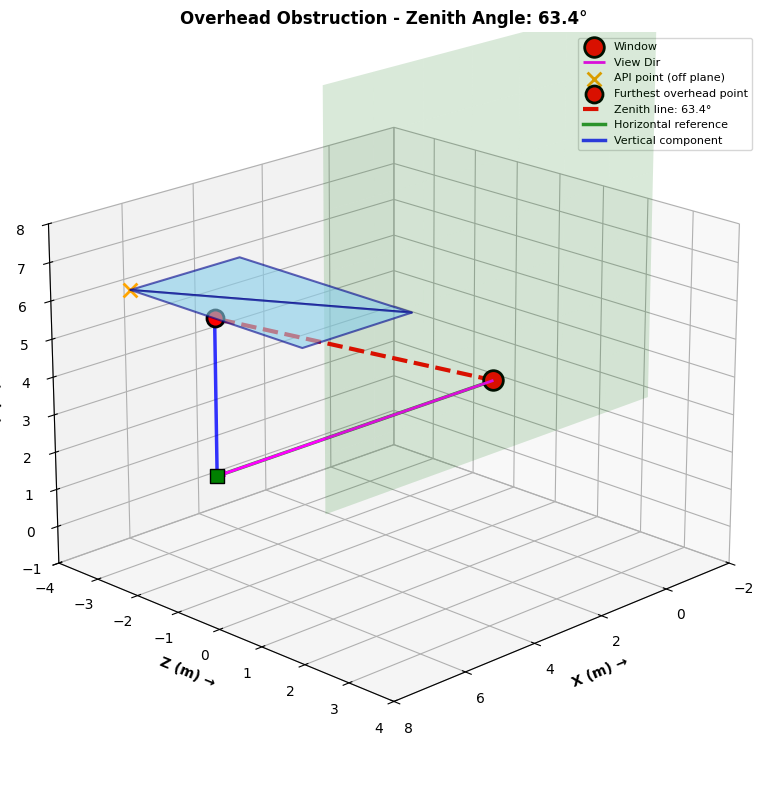

In [42]:
if overhead_result.get("status") == "success" and zenith_deg > 0:
    # Create visualizer
    visualizer = ZenithAngleVisualizer(
        window_center=[0.0, 3.0, 0.0],
        window_angles=[0.0, 0.0],
        mesh_vertices=overhead_mesh,
        scene_dimensions=(overhead_distance, overhead_height, overhead_width)
    )
    
    # Create figure and visualize
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')
    visualizer.visualize(ax, lowest_pt, zenith_deg)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization - no overhead obstruction found")

### 👉 Obstruction (Both Angles)

Use the `/obstruction` endpoint to calculate both horizon and zenith angles in a single request.

In [44]:
request_data["mesh"] += overhead_mesh
request_data["mesh"]

[[10.0, 0.0, -5.0],
 [10.0, 5.0, -5.0],
 [10.0, 0.0, 5.0],
 [10.0, 0.0, 5.0],
 [10.0, 5.0, -5.0],
 [10.0, 5.0, 5.0],
 [5.0, 7.0, -2.0],
 [5.0, 7.0, 2.0],
 [8.0, 7.0, -2.0],
 [5.0, 7.0, 2.0],
 [8.0, 7.0, 2.0],
 [8.0, 7.0, -2.0]]

In [18]:
response = requests.post(f"{SERVER_URL}/obstruction", json=request_data)
both_result = response.json()

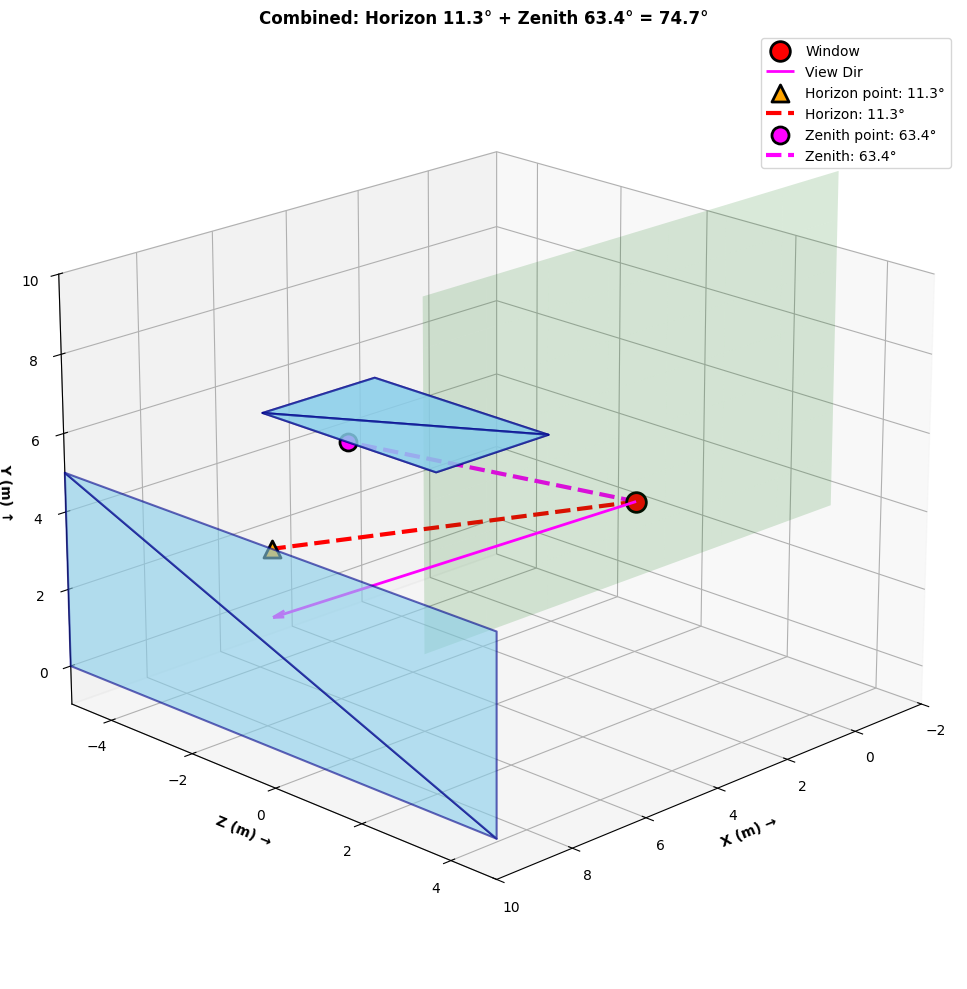


Red line: Horizon angle = 11.3° (upward from horizontal)
Magenta line: Zenith angle = 63.4° (from vertical downward)
Sum: 74.7° (complementary angles)


In [26]:
if both_result.get("status") == "success":
    from viz_utils import (DirectionVectorCalculator, ProjectionPlaneBuilder, 
                           PlotElementRenderer, AxisConfigurator, Color, LineStyle)
    
    # Create figure
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Calculate direction vector and create plane
    calc = DirectionVectorCalculator()
    dir_vec = calc.from_angles(*window_angles)
    horizontal_dir = calc.get_horizontal_component(dir_vec)
    plane_builder = ProjectionPlaneBuilder(window_center, horizontal_dir)
    
    # Setup renderer
    renderer = PlotElementRenderer()
    
    # Add basic scene elements
    renderer.add_window(ax, window_center)
    renderer.add_mesh(ax, overhead_mesh)
    renderer.add_mesh(ax, mesh)
    renderer.add_viewing_direction(ax, window_center, dir_vec, building_dist)
    renderer.add_projection_plane(ax, plane_builder, width=12, height_range=(-2, building_height + 2))

    horizon_angle = both_result["data"]["horizon"]["obstruction_angle_degrees"]
    horizon_data = both_result["data"]["horizon"]
    zenith_angle = both_result["data"]["zenith"]["obstruction_angle_degrees"]
    zenith_data = both_result["data"]["zenith"]
    
    # Add horizon angle visualization (if exists)
    if horizon_angle > 0 and horizon_data.get('highest_point'):
        hp = horizon_data['highest_point']
        hp_3d = np.array([hp['x'], hp['y'], hp['z']])
        hp_proj = plane_builder.project_point(hp_3d)
        
        # Add highest point marker
        ax.scatter(hp_proj[0], hp_proj[2], hp_proj[1], 
                   c=Color.ORANGE.value, s=150, marker='^',
                   label=f'Horizon point: {horizon_angle:.1f}°',
                   edgecolors=Color.BLACK.value, lw=2)
        
        # Add horizon line (red dashed)
        ax.plot([window_center[0], hp_proj[0]], 
                [window_center[2], hp_proj[2]], 
                [window_center[1], hp_proj[1]],
                color=Color.RED.value, linestyle=LineStyle.DASHED.value, 
                lw=3, label=f'Horizon: {horizon_angle:.1f}°')
    
    # Add zenith angle visualization (if exists)
    if zenith_angle > 0 and zenith_data.get('highest_point'):
        
        zp = zenith_data['highest_point']
        zp_3d = np.array([zp['x'], zp['y'], zp['z']])
        zp_proj = plane_builder.project_point(zp_3d)
        
        # Add furthest overhead point marker
        ax.scatter(zp_proj[0], zp_proj[2], zp_proj[1],
                   c=Color.MAGENTA.value, s=150, marker='o',
                   label=f'Zenith point: {zenith_angle:.1f}°',
                   edgecolors=Color.BLACK.value, lw=2)
        
        # Add zenith line (magenta dashed)
        ax.plot([window_center[0], zp_proj[0]], 
                [window_center[2], zp_proj[2]], 
                [window_center[1], zp_proj[1]],
                color=Color.MAGENTA.value, linestyle=LineStyle.DASHED.value,
                lw=3, label=f'Zenith: {zenith_angle:.1f}°')
    
    # Configure axes
    max_range = max(building_dist, building_height, building_width)
    AxisConfigurator.setup(ax, max_range=max_range,
                          title=f'Combined: Horizon {horizon_angle:.1f}° + Zenith {zenith_angle:.1f}° = {horizon_angle + zenith_angle:.1f}°')
    ax.legend(fontsize=10, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nRed line: Horizon angle = {horizon_angle:.1f}° (upward from horizontal)")
    print(f"Magenta line: Zenith angle = {zenith_angle:.1f}° (from vertical downward)")
    print(f"Sum: {horizon_angle + zenith_angle:.1f}° (complementary angles)")
else:
    print("Skipping visualization - obstruction calculation failed")